## Individual Game Logs by Pitch

Baseball Savant's Statcast search provides pitch-level records. The next cells request Statcast data for each batter on a given team in a given season for each pitch they see.

CSV Documentation: https://baseballsavant.mlb.com/csv-docs

In [86]:
from io import StringIO
from pathlib import Path
import pandas as pd
import numpy as np
import requests
import calendar
from calendar import monthrange
from datetime import date

STATCAST_URL = 'https://baseballsavant.mlb.com/statcast_search/csv'
SEASON = {2025, 2026}
TEAM = {'NYY', 'WSH'} #Team Abbreviation (ex: 'NYY' for Yankees)

CURRENT_DIR = Path.cwd()

DATA_DIR = CURRENT_DIR.parent / 'data'
DATA_DIR.mkdir(exist_ok=True)

RAW_DATA_DIR = DATA_DIR / 'raw'
RAW_DATA_DIR.mkdir(exist_ok=True)

PROCESSED_DATA_DIR = DATA_DIR / 'processed'
PROCESSED_DATA_DIR.mkdir(exist_ok=True)

RAW_DATA_FILE = RAW_DATA_DIR / f'complete_pitch_log.csv'
PA_RESULT_FILE = PROCESSED_DATA_DIR / f'pa_results.csv'
LINE_SCORE_FILE = PROCESSED_DATA_DIR / f'line_scores.csv'
GAME_SCORES_FILE = PROCESSED_DATA_DIR / f'player_game_scores.csv'

In [87]:
def get_statcast_month(season, month, team=''):
    start_date = date(season, month, 1)
    end_date = date(season, month, monthrange(season, month)[1])
    params = {
        'all': 'true',
        'type': 'batter',
        'player_type': 'batter',
        'game_type': 'r',
        'hfSea': f'{season}|',
        'hfTeam': f'{team}|' if team else '',
        'game_date_gt': start_date.isoformat(),
        'game_date_lt': end_date.isoformat(),
    }
    response = requests.get(STATCAST_URL, params=params, timeout=120)
    response.raise_for_status()
    if not response.text.strip():
        return pd.DataFrame()
    return pd.read_csv(StringIO(response.text), low_memory=False)

# Truncates dataset to all pitch/swing stats for a given plate appearance where the result was an event (hit, walk, etc.)
def build_plate_appearance_logs(statcast_df):
    
    hit_events = {'single', 'double', 'triple', 'home_run'}
    non_ab_events = {
        'walk', 'intent_walk', 'hit_by_pitch', 'sac_bunt',
        'sac_fly', 'sac_fly_double_play', 'catcher_interf',
    }
    non_pa_events = {'truncated_pa'} #Ex: runner caught stealing and inning ends (not an official PA for batter)
    non_rbi_events = {'field_error', 'sac_fly_double_play', 'grounded_into_double_play', 'double_play', 'triple_play', 'strikeout_double_play'}

    pa_results = statcast_df[statcast_df['events'].notna()].copy()

    pa_results['batter'] = pd.to_numeric(pa_results['batter'], errors='coerce').astype('Int64')
    pa_results['pa'] = (~pa_results['events'].isin(non_pa_events)).astype(int)
    pa_results['ab'] = (~pa_results['events'].isin(non_ab_events)).astype(int)
    pa_results['h'] = pa_results['events'].isin(hit_events).astype(int)
    pa_results['singles'] = (pa_results['events'] == 'single').astype(int)
    pa_results['doubles'] = (pa_results['events'] == 'double').astype(int)
    pa_results['triples'] = (pa_results['events'] == 'triple').astype(int)
    pa_results['hr'] = (pa_results['events'] == 'home_run').astype(int)

    score_change = (
        pd.to_numeric(pa_results['post_bat_score'], errors='coerce')
        - pd.to_numeric(pa_results['bat_score'], errors='coerce')
    )

    pa_results['rbi'] = score_change.where(~pa_results['events'].isin(non_rbi_events), 0)
    pa_results['bb'] = pa_results['events'].isin({'walk', 'intent_walk'}).astype(int)
    pa_results['hbp'] = (pa_results['events'] == 'hit_by_pitch').astype(int)
    pa_results['so'] = pa_results['events'].isin({'strikeout', 'strikeout_double_play'}).astype(int)
    pa_results['sb'] = pa_results['events'].str.startswith('stolen_base', na=False).astype(int)
    pa_results['cs'] = pa_results['events'].str.startswith('caught_stealing', na=False).astype(int)
    pa_results['tb'] = (
        pa_results['singles']
        + (2 * pa_results['doubles'])
        + (3 * pa_results['triples'])
        + (4 * pa_results['hr'])
    )

    return pa_results

# Groups plate appearances by game and player, summing the relevant stats to create a game log for each player in each game
def build_game_logs(pa_results):
    if pa_results.empty:
        return pd.DataFrame()

    pa_results = pa_results.copy()
    
    pa_results['opposing_team'] = np.where(
        pa_results['home_team'] == pa_results['team'],
        pa_results['away_team'],
        pa_results['home_team']
    )

    group_columns = ['game_pk', 'game_date', 'batter', 'player_name', 'team', 'opposing_team', 'season']
    game_logs = pa_results.groupby(group_columns, as_index=False)[[
        'pa', 'ab', 'h', 'singles', 'doubles', 'triples', 'hr',
        'bb', 'hbp', 'so', 'sb', 'cs', 'rbi', 'tb',
    ]].sum()

    game_logs = game_logs.rename(columns={'batter': 'player_id'})
    
    #game_logs.head(50)

    return game_logs

def pa_statcast_data(statcast_df):

    desc_df = statcast_df[statcast_df['description'].notna()].copy()
   
    # Calculate plate appearances and at bats based on the events column, where certain events do not count as official plate appearances or at bats
    non_ab_events = {
        'walk', 'intent_walk', 'hit_by_pitch', 'sac_bunt',
        'sac_fly', 'sac_fly_double_play', 'catcher_interf',
    }
    non_pa_events = {'truncated_pa'} #Ex: runner caught stealing and inning ends (not an official PA for batter)
    desc_df['pa'] = (~desc_df['events'].isin(non_pa_events)).astype(int)
    desc_df['ab'] = (~desc_df['events'].isin(non_ab_events)).astype(int)

    # Handle missing pitch types for automatic balls/strikes, naming the pitch type as "AUTO"
    desc_df['pitch_type'] = np.where((desc_df['description'].str.contains('automatic', na=False)) & (desc_df['pitch_type'].isna()), "AUTO", desc_df['pitch_type'])

    # Count each pitch type for the plate appearance grouped by game and at-bat. Keep NaN values for rows missing pitch types (not including automatic balls/strikes)
    pitch_type_counts = (
        desc_df.groupby(['game_pk', 'at_bat_number', 'pitch_type'], dropna=False)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    pitch_type_counts.columns.name = None

    pitch_cols = [col for col in pitch_type_counts.columns if col not in {'game_pk', 'at_bat_number'}]
    for col in pitch_cols:
        pitch_type_counts[col] = pitch_type_counts[col].fillna(0).astype(int)

    # Get a list of unique result types from the 'description' column
    pitch_result_events = desc_df['description'].unique()
    pitch_result_events = pd.Series(pitch_result_events).to_dict()

    desc_df['swings'] = desc_df.groupby(['game_pk', 'at_bat_number'])['description'].transform(
        lambda x: x.isin({
            'hit_into_play', 'swinging_strike', 'foul', 'foul_tip',
            'swinging_strike_blocked', 'foul_bunt', 'missed_bunt',
            'bunt_foul_tip'
        }).sum()
        ).astype(int) # Count of all swings

    desc_df['pitches'] = desc_df.groupby(['game_pk', 'at_bat_number'])['description'].transform('count').astype(int) # Count of all pitches
    desc_df['balls'] = desc_df.groupby(['game_pk', 'at_bat_number'])['type'].transform(
        lambda x: x.isin({'B'}).sum()
        ).astype(int) # Count of all balls
    desc_df['strikes'] = desc_df.groupby(['game_pk', 'at_bat_number'])['type'].transform(
        lambda x: x.isin({'S'}).sum()
        ).astype(int) # Count of all strikes
    desc_df['in_play'] = desc_df.groupby(['game_pk', 'at_bat_number'])['type'].transform(
        lambda x: x.isin({'X'}).sum()
        ).astype(int) # Count of all strikes

    # Combine original df with pitch type counts for each plate appearance
    pa_statcast_df = desc_df[desc_df['events'].notna()].copy()
    
    if 'bb_type' not in pa_statcast_df.columns:
            pa_statcast_df['bb_type'] = np.nan

    pa_statcast_df = pa_statcast_df.merge(
        pitch_type_counts,
        on=['game_pk', 'at_bat_number'],
        how='left'
    )

    for col in pitch_cols:
        pa_statcast_df[col] = pa_statcast_df[col].fillna(0).astype(int)


    ## More granular, smaller dataframe for season-long analysis for individual players
    group_cols = ['batter', 'player_name', 'season', 'team']
    pitches_by_player_cols = ['pa', 'ab', 'pitches', 'balls', 'strikes', 'in_play', 'swings'] + pitch_cols
    pitches_by_player = pa_statcast_df.groupby(group_cols, as_index=False)[
        pitches_by_player_cols
    ].sum().reset_index(drop=True)


    return pa_statcast_df, pitches_by_player


In [88]:
# Run data retrieval for each month of the season into a single dataframe
monthly_statcast = []
for season in SEASON:
    for team in  TEAM:
        for month in range(1, 13):
            month_df = get_statcast_month(season, month, team)
            month_df['team'] = team
            month_name = calendar.month_name[month]
            if not month_df.empty:
                monthly_statcast.append(month_df)
            print(f'INFO: Processed data for {month_name}, {season} // {team} //   Rows fetched: {sum(len(df) for df in monthly_statcast)}')

statcast_df = pd.concat(monthly_statcast, ignore_index=True)
statcast_df = statcast_df.dropna(how='all', axis=1) # Drop empty columns
statcast_df = statcast_df.loc[:, ~statcast_df.columns.str.startswith('fielder')] # Drop columns with no useful info
statcast_df = statcast_df[statcast_df['game_type'] == 'R']  # Filter for regular season games only
statcast_df['pitch_type_id'] = statcast_df['pitch_type'].factorize()[0] # Enumerate pitch types for easier analysis and modeling
statcast_df['on_1b'] = statcast_df['on_1b'].fillna(0).astype(int) # Replace missing values with 0 for runners on base
statcast_df['on_2b'] = statcast_df['on_2b'].fillna(0).astype(int)
statcast_df['on_3b'] = statcast_df['on_3b'].fillna(0).astype(int)
statcast_df.loc[statcast_df['on_1b'] > 1, 'on_1b'] = 1 # Cap runners on base at 1 for each base
statcast_df.loc[statcast_df['on_2b'] > 1, 'on_2b'] = 1
statcast_df.loc[statcast_df['on_3b'] > 1, 'on_3b'] = 1
statcast_df = statcast_df.rename(columns={'game_year': 'season'})
statcast_df = statcast_df.sort_values(by=['game_date', 'team', 'at_bat_number', 'pitch_number'], ascending=True)
statcast_df.to_csv(RAW_DATA_FILE, index=False, encoding='utf-8') #utf-8-sig for excel

INFO: Processed data for January, 2025 // WSH //   Rows fetched: 0
INFO: Processed data for February, 2025 // WSH //   Rows fetched: 947
INFO: Processed data for March, 2025 // WSH //   Rows fetched: 5250
INFO: Processed data for April, 2025 // WSH //   Rows fetched: 9050
INFO: Processed data for May, 2025 // WSH //   Rows fetched: 12840
INFO: Processed data for June, 2025 // WSH //   Rows fetched: 16509
INFO: Processed data for July, 2025 // WSH //   Rows fetched: 20030
INFO: Processed data for August, 2025 // WSH //   Rows fetched: 24030
INFO: Processed data for September, 2025 // WSH //   Rows fetched: 27560
INFO: Processed data for October, 2025 // WSH //   Rows fetched: 27560
INFO: Processed data for November, 2025 // WSH //   Rows fetched: 27560
INFO: Processed data for December, 2025 // WSH //   Rows fetched: 27560
INFO: Processed data for January, 2025 // NYY //   Rows fetched: 27560
INFO: Processed data for February, 2025 // NYY //   Rows fetched: 28600
INFO: Processed data fo

In [89]:
# Process and break up entire pitch log dataset into plate appearance and individual game line score datasets
if not statcast_df.empty:
    pa_statcast = build_plate_appearance_logs(statcast_df)
    pa_statcast.to_csv(PA_RESULT_FILE, index=False, encoding='utf-8')
    #print(f'Wrote {len(pa_df)} plate appearance result rows to {PA_RESULT_FILE}')
    if not pa_df.empty:
        line_score_df = build_game_logs(pa_df)
        line_score_df.to_csv(LINE_SCORE_FILE, index=False, encoding='utf-8')
        #print(f'Wrote {len(line_score_df)} player-game rows to {LINE_SCORE_FILE}')
else:
    statcast_df = pd.DataFrame()
    pa_df = pd.DataFrame()
    print('No Statcast game-log data was found.')

In [90]:
pa_statcast, by_player = pa_statcast_data(statcast_df)
#pa_statcast.describe(include='all')

In [91]:
by_player[by_player['season'] == 2026].head(100)

,batter,player_name,season,team,pa,ab,pitches,balls,strikes,in_play,...,FS,KC,KN,PO,SI,SL,ST,SV,UN,NaN
1,502671,"Goldschmidt, Paul",2026,NYY,371,337,1469,494,721,254,...,29,19,0,0,261,246,125,6,0,3
4,519317,"Stanton, Giancarlo",2026,NYY,96,90,384,146,177,61,...,7,5,0,0,67,54,36,0,0,0
5,545341,"Grichuk, Randal",2026,NYY,33,31,120,41,57,22,...,1,1,0,0,14,15,6,0,0,0
6,571945,"Mikolas, Miles",2026,WSH,1,0,3,1,1,1,...,0,0,0,0,0,0,0,0,0,0
8,592450,"Judge, Aaron",2026,NYY,285,237,1234,501,580,153,...,43,6,0,0,187,210,100,5,0,0
14,641355,"Bellinger, Cody",2026,NYY,554,489,2076,765,903,408,...,95,23,0,0,342,253,142,4,0,1
16,641555,"Escarra, J.C.",2026,NYY,92,85,350,129,153,68,...,16,6,0,0,44,40,28,1,0,0
18,641857,"McMahon, Ryan",2026,NYY,352,321,1438,511,708,219,...,63,30,0,2,169,186,112,2,0,3
21,642708,"Rosario, Amed",2026,NYY,236,219,856,264,426,166,...,14,9,0,0,146,120,68,7,0,0
22,645305,"Sánchez, Ali",2026,NYY,84,79,294,95,143,56,...,3,0,0,0,66,25,18,1,0,0


## Important Considerations for Game Score
- Chases and how bad was the chase (miss distance, bat speed)
- Velocity / spin rate correlation based on pitch type
- Situation (runners on, inning, num outs)
- Exit velo / hit distance / xBA
- Result for plate appearances (type of event, RBIs, WPA)

TODO: Incorporate in some formulas for these factors

## Potentially Important Features for a More Complex Model:

1. Pitch Type - need to enumerate
2. Game Date ?
3. pfx_x and pfx_z (horizontal and vertical movement, respectively, of pitch from release to crossing plate, from catcher's perspective)
4. Zone:

    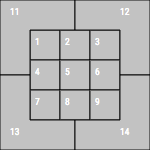

5. Event - need to enumerate
6. Stand (batter L/R), p_throws (pitcher L/R)
7. Type (ball/strike/in play) - enumerate
8. Hit location (pos. of fielder)
9. bb_type (batted ball type - line drive, fly ball, etc) - enumerate
10. Count (balls / strikes)
11. Runners on
12. Current # of outs
13. Inning
14. sz_top / sz_bot (top/bottom of batter's strike zone}
15. hit_distance
16. launch_speed
17. effective_speed (derived speed based on pitcher's extension)
18. release_pos_y (release position of pitch measured in feet from the catcher's perspective)
19. release_spin (spin rate)
20. release_extension
21. arm_angle
22. score before/after event
23. bat_speed
24. swing_length
25. miss_distance


In [92]:
pa_statcast.head(100)

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,FS,KC,KN,PO,SI,SL,ST,SV,UN,NaN
0,FF,2025-03-27,93.4,-3.60,5.43,"Wells, Austin",669224,642547,home_run,hit_into_play,...,0,0,0,0,0,0,0,0,0,0
1,FF,2025-03-27,94.3,-3.34,5.42,"Judge, Aaron",592450,642547,field_out,hit_into_play,...,0,0,0,0,0,0,0,0,0,0
2,FF,2025-03-27,93.6,-3.57,5.40,"Bellinger, Cody",641355,642547,strikeout,swinging_strike,...,0,0,0,0,0,0,0,0,0,0
3,CH,2025-03-27,89.3,-3.79,5.09,"Goldschmidt, Paul",502671,642547,field_out,hit_into_play,...,0,0,0,0,0,0,0,0,0,0
4,CH,2025-03-27,90.3,-3.72,4.98,"Chisholm Jr., Jazz",665862,642547,strikeout,swinging_strike,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,CH,2025-03-29,85.7,1.27,5.37,"Wells, Austin",669224,671162,field_out,hit_into_play,...,0,0,0,0,1,0,2,0,0,0
96,SI,2025-03-29,90.3,1.25,5.13,"Reyes, Pablo",622569,671162,field_out,hit_into_play,...,0,0,0,0,1,0,0,0,0,0
97,SI,2025-03-29,89.3,1.32,5.16,"Domínguez, Jasson",691176,671162,strikeout,called_strike,...,0,0,0,0,3,0,2,0,0,0
98,CH,2025-03-29,84.3,1.27,5.32,"Grisham, Trent",663757,671162,walk,ball,...,0,0,0,0,2,0,2,0,0,0


In [93]:
# Summarize launch angle, launch speed, and hit distance by batted-ball type
# Helpful for creating weights in game score function

for col in ['launch_angle', 'launch_speed', 'hit_distance_sc']:
    if col in statcast_df.columns:
        statcast_df[col] = pd.to_numeric(statcast_df[col], errors='coerce')

bb = statcast_df[statcast_df['bb_type'].notna()].copy()
bb['bb_type'] = bb['bb_type'].astype(str)

summary = (
    bb.groupby('bb_type', dropna=True)
      .agg(
          hit_distance_mean = ('hit_distance_sc', 'mean'),
          hit_distance_std = ('hit_distance_sc', 'std'),
          launch_angle_mean = ('launch_angle', 'mean'),
          launch_angle_std = ('launch_angle', 'std'),
          launch_speed_mean = ('launch_speed', 'mean'),
          launch_speed_std = ('launch_speed', 'std'),
          count = ('bb_type', 'size')
      )
      .reset_index()
)

display(summary)


,bb_type,hit_distance_mean,hit_distance_std,launch_angle_mean,launch_angle_std,launch_speed_mean,launch_speed_std,count
0,fly_ball,317.136868,63.196615,36.907919,9.714009,93.160928,10.257435,4421
1,ground_ball,32.889434,38.539623,-12.758805,18.939989,85.563857,17.337215,6784
2,line_drive,251.294781,71.728163,16.288598,5.578708,94.600210,11.706074,3817
3,popup,124.050725,51.526394,65.415761,11.324128,76.845380,13.231951,1104


In [94]:
# Summarize miss distance and bat speed
# Helpful for creating weights in game score function

for col in ['miss_distance', 'bat_speed']:
    if col in statcast_df.columns:
        statcast_df[col] = pd.to_numeric(statcast_df[col], errors='coerce')

bb = statcast_df[statcast_df['description'].notna()].copy()
bb['description'] = bb['description'].astype(str)

summary = (
    bb.groupby('description', dropna=True)
      .agg(
          miss_distance_mean = ('miss_distance', 'mean'),
          miss_distance_std = ('miss_distance', 'std'),
          bat_speed_mean = ('bat_speed', 'mean'),
          bat_speed_std = ('bat_speed', 'std'),
          count = ('description', 'size')
      )
      .reset_index()
)

display(summary)

,description,miss_distance_mean,miss_distance_std,bat_speed_mean,bat_speed_std,count
0,automatic_ball,NaN,NaN,NaN,NaN,386
1,automatic_strike,NaN,NaN,NaN,NaN,17
2,ball,NaN,NaN,NaN,NaN,32107
3,blocked_ball,NaN,NaN,NaN,NaN,1956
4,bunt_foul_tip,NaN,NaN,11.780000,6.031335,5
5,called_strike,NaN,NaN,NaN,NaN,15455
6,foul,NaN,NaN,70.679446,7.141944,16524
7,foul_bunt,NaN,NaN,9.367808,4.499286,157
8,foul_tip,0.740742,0.663176,71.480884,7.065514,977
9,hit_by_pitch,NaN,NaN,NaN,NaN,217


In [ ]:
"""
- Per-player, per-game game score from the full Statcast pitch log.
- Accounts every pitch seen by the batter in a game, accounting for results, quality of contact, swing/miss metrics, pitch metrics
- NEXT STEPS:
    - Add more granular pitch metrics to the scoring algorithm, including pitch location, movement, and spin rate.
    - Consider adding weights for different pitch types and their effectiveness against specific batters.
    - Develop a rolling scoring system that accounts for a player's performance over a given span of games
        - Will be useful for evaluating performance trends and using them in predictive modeling
"""
def calculate_game_score(statcast_df, scale=100.0):
    if statcast_df is None or statcast_df.empty:
        return pd.DataFrame(
            columns=[
                "game_pk",
                "game_date",
                "player_id",
                "player_name",
                "team",
                "opposing_team",
                "game_score_raw",
                "game_score",
            ]
        )

    pitches = statcast_df.copy()

    # Basic game / player identifiers
    pitches["player_id"] = pd.to_numeric(pitches["batter"], errors="coerce").astype("Int64")
    pitches["player_name"] = pitches["player_name"].fillna("")
    pitches["game_date"] = pd.to_datetime(pitches["game_date"], errors="coerce").dt.strftime("%Y-%m-%d")

    # Relevant contextual pitch/situation metrics
    for col in [
        "release_speed",
        "release_spin_rate",
        "launch_speed",
        "hit_distance_sc",
        "launch_angle",
        "bat_speed",
        "swing_length",
        "miss_distance",
        "woba_value",
        "delta_run_exp",
        "on_1b",
        "on_2b",
        "on_3b",
        "outs_when_up",
        "inning",
        "arm_angle",
        "pfx_x",
        "pfx_z",
        "api_break_x_arm",
        "api_break_z_with_gravity",
    ]:
        if col in pitches.columns:
            pitches[col] = pd.to_numeric(pitches[col], errors="coerce")

    pitches["pitch_type_id"] = pd.to_numeric(pitches["pitch_type_id"], errors="coerce").fillna(0)

    pitches["runners_on"] = 0.0
    for base_col in ["on_1b", "on_2b", "on_3b"]:
        if base_col in pitches.columns:
            pitches["runners_on"] += pd.to_numeric(pitches[base_col], errors="coerce").fillna(0)

    if "events" in pitches.columns:
        pitches["events_clean"] = pitches["events"].fillna("").str.lower().str.replace(" ", "_", regex=False)
    else:
        pitches["events_clean"] = ""

    if "description" in pitches.columns:
        pitches["description_clean"] = pitches["description"].fillna("").str.lower()
    else:
        pitches["description_clean"] = ""

    # Outcome weights based on pitch result and quality of contact
    event_map = {
        "single": 15,
        "double": 30,
        "triple": 45,
        "home_run": 60,
        "walk": 15,
        "hit_by_pitch": 10,
        "strikeout": -20,
        "field_out": -10,
        "grounded_into_double_play": -30,
        "double_play": -30,
        "sac_fly": 8,
        "sac_bunt": 6,
        "force_out": -6,
        "lineout": -5,
        "flyout": -4,
        "error": 5,
        "fielders_choice": 5,
        "batter_interference": 5,
        "intent_walk": 15,
    }

    def pitch_score(row):
        score = 0.0

        event = row["events_clean"]
        desc = row["description_clean"]
        score += event_map.get(event, 0)

        # Pitch-specific stuff / shape adjustments
        #score += float(row.get("pitch_type_id", 0)) * 0.8

        if pd.notna(row.get("pfx_z")):
            score += max(0.0, abs(float(row["pfx_z"])) - 5) * 0.2
        if pd.notna(row.get("pfx_x")):
            score += max(0.0, abs(float(row["pfx_x"])) - 5) * 0.2

        #if pd.notna(row.get("woba_value")):
        #    score += float(row["woba_value"]) * 22

        if pd.notna(row.get("launch_speed")):
            score += max(0.0, (float(row["launch_speed"]) - 88) * 0.5) # League average approx 88 mph

        # TO DO: TUNE WEIGHTS FOR CONTACT TYPES
        if pd.notna(row.get("bb_type")) and row["bb_type"] == "ground_ball":
            if pd.notna(row.get("hit_distance_sc")):
                score += max(0.0, (float(row["hit_distance_sc"]) - 30) * 0.05) # Calculated average approx 30 ft for ground balls

        if pd.notna(row.get("bb_type")) and row["bb_type"] == "popup":
            if pd.notna(row.get("hit_distance_sc")):
                score += max(0.0, (float(row["hit_distance_sc"]) - 125) * 0.05) # Calculated average approx 125 ft for popups

        if pd.notna(row.get("bb_type")) and row["bb_type"] == "line_drive":
            if pd.notna(row.get("hit_distance_sc")):
                score += max(0.0, (float(row["hit_distance_sc"]) - 250) * 0.05) # Calculated average approx 250 ft for line drives

        if pd.notna(row.get("bb_type")) and row["bb_type"] == "fly_ball":
            if pd.notna(row.get("hit_distance_sc")):
                score += max(0.0, (float(row["hit_distance_sc"]) - 315) * 0.05) # Calculated average approx 315 ft for popups

        if pd.notna(row.get("delta_run_exp")):
            score += float(row["delta_run_exp"]) * 15

        # Situational value
        runners_on = row.get("runners_on", 0)
        outs = row.get("outs_when_up", 0)
        inning = row.get("inning", 0)

        score += float(runners_on) * 2.5
        if outs >= 2:
            score += 4
        if inning >= 7:
            score += 3

        # Chase / poor swing penalties
        # DETERMINE AVERAGES / WEIGHTS
        if any(token in desc for token in ["swinging_strike", "called_strike", "missed_bunt"]):
            score -= 6

        if pd.notna(row.get("miss_distance")):
            miss_distance = float(row["miss_distance"])
            score -= max(0.0, (miss_distance - 8) * 0.8)

        if pd.notna(row.get("bat_speed")):
            bat_speed = float(row["bat_speed"])
            if bat_speed < 60:
                score -= 2

        # Pitch quality / velocity and spin considerations
        # DETERMINE AVERAGES / WEIGHTS
        if pd.notna(row.get("release_speed")):
            score += max(0.0, (float(row["release_speed"]) - 87) * 0.2)

        if pd.notna(row.get("release_spin_rate")):
            score += max(0.0, (float(row["release_spin_rate"]) - 1800) / 200)

        return score

    pitches["pitch_score"] = pitches.apply(pitch_score, axis=1)

    game_score_df = (
        pitches.groupby(["game_pk", "game_date", "player_id", "player_name", "team"], dropna=False, as_index=False)["pitch_score"]
        .sum()
        .rename(columns={"pitch_score": "game_score_raw"})
    )

    if "home_team" in pitches.columns and "away_team" in pitches.columns:
        lookup = pitches[["game_pk", "team", "home_team", "away_team"]].drop_duplicates()
        game_score_df = game_score_df.merge(lookup, on=["game_pk", "team"], how="left")
        game_score_df["opposing_team"] = np.where(
            game_score_df["team"] == game_score_df["home_team"],
            game_score_df["away_team"],
            game_score_df["home_team"],
        )
    else:
        game_score_df["opposing_team"] = np.nan

    # Normalize raw total scores
    game_score_df["game_score"] = 0.0
    if not game_score_df.empty:
        raw_min = game_score_df["game_score_raw"].min()
        raw_max = game_score_df["game_score_raw"].max()
        if raw_max > raw_min:
            game_score_df["game_score"] = (game_score_df["game_score_raw"] - raw_min) / (raw_max - raw_min) * scale
        game_score_df["game_score"] = game_score_df["game_score"].clip(lower=0, upper=scale)

    return game_score_df[["game_pk", "game_date", "player_id", "player_name", "team", "opposing_team", "game_score_raw", "game_score"]]

# Use the full pitch-level Statcast dataframe so every pitch seen in a game contributes
player_game_scores = calculate_game_score(statcast_df)

if not player_game_scores.empty:
    player_game_scores = (
        line_score_df[["game_pk", "game_date", "player_id", "player_name", "team", "opposing_team", "season"]]
        .merge(player_game_scores, on=["game_pk", "game_date", "player_id", "player_name", "team"], how="left")
    )
    player_game_scores["game_score"] = player_game_scores["game_score"].fillna(0).clip(lower=0, upper=100)
    player_game_scores = player_game_scores.sort_values(["game_date", "player_name", "game_pk"]).reset_index(drop=True)
    display(player_game_scores.head(10))
    player_game_scores.to_csv(GAME_SCORES_FILE, index=False, encoding='utf-8')
else:
    print("INFO: No game scores were generated from the pitch log.")


,game_pk,game_date,player_id,player_name,team,opposing_team_x,season,opposing_team_y,game_score_raw,game_score
0,778555,2025-03-27,682928,"Abrams, CJ",WSH,PHI,2025,PHI,70.660000,28.416660
1,778555,2025-03-27,605137,"Bell, Josh",WSH,PHI,2025,PHI,66.630000,27.692007
2,778557,2025-03-27,641355,"Bellinger, Cody",NYY,MIL,2025,MIL,139.925000,40.871527
3,778557,2025-03-27,665828,"Cabrera, Oswaldo",NYY,MIL,2025,MIL,74.780000,29.157497
4,778557,2025-03-27,665862,"Chisholm Jr., Jazz",NYY,MIL,2025,MIL,27.864913,20.721474
5,778555,2025-03-27,686611,"Crews, Dylan",WSH,PHI,2025,PHI,102.535000,34.148255
6,778555,2025-03-27,657557,"DeJong, Paul",WSH,PHI,2025,PHI,-9.010000,14.090822
7,778557,2025-03-27,691176,"Domínguez, Jasson",NYY,MIL,2025,MIL,3.140000,16.275571
8,778555,2025-03-27,671277,"García Jr., Luis",WSH,PHI,2025,PHI,117.896381,36.910457
9,778557,2025-03-27,502671,"Goldschmidt, Paul",NYY,MIL,2025,MIL,-3.460000,15.088794
